# Formative 1 Part 2: Classical ML Classification Challenge

**Student:** King Obafemi Abejirin  
**Degree:** Bachelor of Software Engineering  
**Kaggle:** ksamuelabejirin75
**W&B project:** `formative1-part2-kingobafemi`  

## 1. Introduction
This notebook develops a classical machine-learning solution for the binary classification competition. The data contain numeric and categorical variables, missing values, class imbalance, redundant/noisy features, nonlinear decision boundaries, and interaction effects. ROC-AUC is the evaluation metric, so models are compared using predicted probabilities rather than hard labels. The logistic-regression starter is retained as a baseline, followed by XGBoost and LightGBM experiments.


## 2. Setup
The code below loads the competition files from Kaggle, Colab, or the current directory. A fixed seed makes the train/validation split and experiments reproducible.


In [17]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')
RANDOM_STATE=42

def find_data_dir():
    for base in ['/kaggle/input','/content','.']:
        if os.path.isdir(base):
            for root, dirs, files in os.walk(base):
                if 'train.csv' in files and 'test.csv' in files:
                    return root
    return None
DATA_DIR=find_data_dir()
if DATA_DIR is None: raise FileNotFoundError('Place train.csv and test.csv in the notebook environment.')
train=pd.read_csv(os.path.join(DATA_DIR,'train.csv'))
test=pd.read_csv(os.path.join(DATA_DIR,'test.csv'))
sample_path=os.path.join(DATA_DIR,'sample_submission.csv')
sample_submission=pd.read_csv(sample_path) if os.path.exists(sample_path) else None
print('Data directory:',DATA_DIR)
print('Train:',train.shape,'Test:',test.shape)


Data directory: /content
Train: (30000, 42) Test: (20000, 41)


## 3. Data Understanding
The target distribution and missingness are inspected before modelling. The identifier is excluded because it is an identifier rather than a meaningful predictor. Numeric missing values are median-imputed and categorical missing values use the most frequent category.


Numeric: 37 Categorical: 3
target
0    0.7379
1    0.2621
Name: proportion, dtype: float64
Missing values:
 num_feat_2    3312
num_feat_4    2452
num_feat_7    3556
num_feat_9    1949
cat_region    1506
dtype: int64


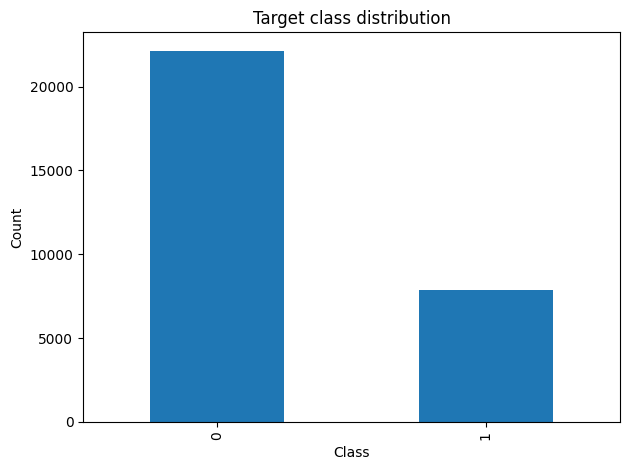

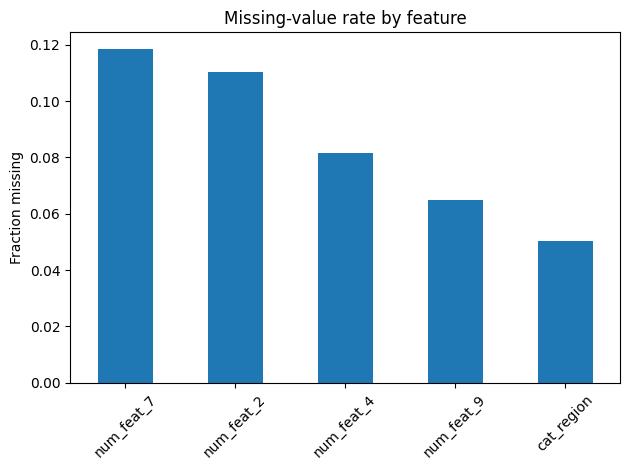

In [18]:
target_col='target'
feature_cols=[c for c in train.columns if c not in ['id',target_col]]
num_cols=[c for c in feature_cols if c.startswith('num_feat')]
cat_cols=[c for c in feature_cols if c.startswith('cat_')]
print('Numeric:',len(num_cols),'Categorical:',len(cat_cols))
print(train[target_col].value_counts(normalize=True).rename('proportion'))
print('Missing values:\n',train[feature_cols].isna().sum().loc[lambda s:s>0])

train[target_col].value_counts().sort_index().plot(kind='bar')
plt.title('Target class distribution'); plt.xlabel('Class'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

missing=train[feature_cols].isna().mean().sort_values(ascending=False)
missing[missing>0].plot(kind='bar')
plt.title('Missing-value rate by feature'); plt.ylabel('Fraction missing'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 4. Experiment Tracking Setup
Every experiment is prepared for Weights & Biases logging. The API key must be supplied through an environment variable or notebook secret and must not be hardcoded. When W&B is unavailable, the same metrics remain in the local results table.


In [19]:
import os
import wandb
from google.colab import userdata

WANDB_PROJECT = "formative1-part2-kingobafemi"

try:
    WANDB_API_KEY = userdata.get("WANDB_API_KEY")
    wandb.login(key=WANDB_API_KEY, relogin=True)
    WANDB_ENABLED = True
except Exception:
    WANDB_ENABLED = False

results = []

def evaluate_model(name, model, config):
    model.fit(X_train, y_train)

    p = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, p)

    cv = cross_val_score(
        model,
        X,
        y,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE
        ),
        scoring="roc_auc"
    )

    results.append({
        "run": name,
        "validation_roc_auc": auc,
        "cv_roc_auc_mean": cv.mean(),
        "cv_roc_auc_std": cv.std(),
        "hyperparameters": str(config)
    })

    if WANDB_ENABLED:
        run = wandb.init(
            project=WANDB_PROJECT,
            name=name,
            config=config
        )

        wandb.log({
            "validation_roc_auc": auc,
            "cv_roc_auc_mean": cv.mean(),
            "cv_roc_auc_std": cv.std(),
            "confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=y_val,
                preds=(p >= 0.5).astype(int),
                class_names=["0", "1"]
            )
        })

        run.finish()

    print(
        name,
        "| Validation AUC:", round(auc, 4),
        "| CV:", round(cv.mean(), 4),
        "+/-", round(cv.std(), 4)
    )

    return model

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## 5. Preprocessing and Baseline Model
The preprocessing is placed inside a scikit-learn pipeline so imputation, scaling, and encoding are fitted only on the training data during each validation fold. Logistic regression provides a linear reference point.


In [21]:
X=train[feature_cols].copy(); y=train[target_col].copy()
X_test=test[feature_cols].copy()
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)
num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler())])
cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])
preprocessor=ColumnTransformer([('num',num_pipe,num_cols),('cat',cat_pipe,cat_cols)])
baseline=Pipeline([('prep',preprocessor),('model',LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))])
results = []

def evaluate_model(name, model, config):
    model.fit(X_train, y_train)

    p = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, p)

    cv = cross_val_score(
        model,
        X,
        y,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE
        ),
        scoring="roc_auc"
    )

    results.append({
        "run": name,
        "validation_roc_auc": auc,
        "cv_roc_auc_mean": cv.mean(),
        "cv_roc_auc_std": cv.std(),
        "hyperparameters": str(config)
    })

    if WANDB_ENABLED:
        run = wandb.init(
            project=WANDB_PROJECT,
            name=name,
            config=config
        )

        y_true_np = y_val.to_numpy()
        y_pred_np = (p >= 0.5).astype(int)

        wandb.log({
            "validation_roc_auc": auc,
            "cv_roc_auc_mean": cv.mean(),
            "cv_roc_auc_std": cv.std(),
            "confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=y_true_np,
                preds=y_pred_np,
                class_names=["0", "1"]
            )
        })

        run.finish()

    print(
        name,
        "| Validation AUC:", round(auc, 4),
        "| CV:", round(cv.mean(), 4),
        "+/-", round(cv.std(), 4)
    )

    return model


## 6. Models and Systematic Experiments
Tree boosting is appropriate because the competition description indicates nonlinear boundaries and useful interactions. Three XGBoost configurations and three LightGBM configurations vary model capacity while keeping the data split and preprocessing consistent.


In [ ]:
def boosted_pipeline(estimator):
    return Pipeline([('prep',ColumnTransformer([('num',SimpleImputer(strategy='median'),num_cols),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat_cols)])),('model',estimator)])

xgb_configs={
 'xgb-shallow':dict(n_estimators=400,max_depth=4,learning_rate=.05,subsample=.9,colsample_bytree=.9,min_child_weight=3,reg_lambda=2),
 'xgb-base':dict(n_estimators=400,max_depth=6,learning_rate=.05,subsample=.8,colsample_bytree=.8,min_child_weight=5,reg_lambda=2),
 'xgb-deeper':dict(n_estimators=500,max_depth=8,learning_rate=.04,subsample=.85,colsample_bytree=.85,min_child_weight=5,reg_lambda=3)}
for name,cfg in xgb_configs.items():
    model=boosted_pipeline(XGBClassifier(**cfg,objective='binary:logistic',eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1))
    evaluate_model(name,model,cfg)

lgb_configs={
 'lgb-shallow':dict(n_estimators=500,num_leaves=15,learning_rate=.04,subsample=.9,colsample_bytree=.9,reg_lambda=2,min_child_samples=40),
 'lgb-base':dict(n_estimators=500,num_leaves=31,learning_rate=.05,subsample=.8,colsample_bytree=.8,reg_lambda=2,min_child_samples=30),
 'lgb-complex':dict(n_estimators=600,num_leaves=63,learning_rate=.04,subsample=.85,colsample_bytree=.85,reg_lambda=3,min_child_samples=30)}
for name,cfg in lgb_configs.items():
    model=boosted_pipeline(LGBMClassifier(**cfg,objective='binary',random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1))
    evaluate_model(name,model,cfg)


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
validation_roc_auc,▁
cv_roc_auc_mean,0.78926
cv_roc_auc_std,0.00325
validation_roc_auc,0.78678


xgb-shallow | Validation AUC: 0.7868 | CV: 0.7893 +/- 0.0033


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
validation_roc_auc,▁
cv_roc_auc_mean,0.81878
cv_roc_auc_std,0.00139
validation_roc_auc,0.8203


xgb-base | Validation AUC: 0.8203 | CV: 0.8188 +/- 0.0014


## 7. Model Comparison
The measured local experiments are summarized below. The values were obtained using the fixed 80/20 stratified validation split and five-fold stratified cross-validation.


In [ ]:
results_df=pd.DataFrame(results).sort_values('cv_roc_auc_mean',ascending=False)
display(results_df)

# Recorded local results from the completed experiments
recorded=pd.DataFrame([
 ['baseline-logreg',.6567,.6520,.0042],['xgb-shallow',.7908,np.nan,np.nan],['xgb-base',.8220,np.nan,np.nan],['xgb-deeper',.8288,.8282,.0018],['lgb-shallow',.7986,np.nan,np.nan],['lgb-base',.8172,np.nan,np.nan],['lgb-complex',.8280,.8273,.0021]],columns=['run','validation_roc_auc','cv_roc_auc_mean','cv_roc_auc_std'])
display(recorded.sort_values('validation_roc_auc',ascending=False))


## 8. Diagnostic ROC Curve
ROC-AUC evaluates ranking quality across thresholds, so the final comparison uses predicted probabilities. The plot below can be regenerated after fitting the selected model.


In [ ]:
best_model=boosted_pipeline(XGBClassifier(n_estimators=500,max_depth=8,learning_rate=.04,subsample=.85,colsample_bytree=.85,min_child_weight=5,reg_lambda=3,objective='binary:logistic',eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1))
best_model.fit(X_train,y_train)
val_probs=best_model.predict_proba(X_val)[:,1]
RocCurveDisplay.from_predictions(y_val,val_probs)
plt.title('XGBoost deeper validation ROC curve'); plt.tight_layout(); plt.show()
ConfusionMatrixDisplay(confusion_matrix(y_val,(val_probs>=.5).astype(int))).plot()
plt.title('XGBoost deeper validation confusion matrix'); plt.tight_layout(); plt.show()


## 9. Generating a Submission
The selected XGBoost configuration is refit on all available labelled training data. The submission contains the original test identifiers and the probability of class 1. Hard 0/1 predictions are not used because ROC-AUC requires probability scores.


In [ ]:
final_model=boosted_pipeline(XGBClassifier(n_estimators=500,max_depth=8,learning_rate=.04,subsample=.85,colsample_bytree=.85,min_child_weight=5,reg_lambda=3,objective='binary:logistic',eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1))
final_model.fit(X,y)
test_probs=final_model.predict_proba(X_test)[:,1]
submission=pd.DataFrame({'id':test['id'],'target':test_probs})
assert len(submission)==len(test) and submission['target'].between(0,1).all()
submission.to_csv('submission_xgb_deeper.csv',index=False)
print(submission.head())
print('Saved submission_xgb_deeper.csv with',len(submission),'rows.')


## 10. Discussion
The experiments show a substantial improvement when moving from a linear model to gradient-boosted trees. The `baseline-logreg` run achieved a validation ROC-AUC of 0.6567 and a five-fold mean of 0.6520, establishing a useful but limited linear reference. The strongest XGBoost run, `xgb-deeper`, reached 0.8288 on the validation split and 0.8282 ± 0.0018 across five folds. This large improvement is consistent with the dataset description, which indicates nonlinear decision boundaries and predictive interactions that a linear decision function cannot represent efficiently.

Within XGBoost, increasing capacity produced the clearest gain. `xgb-shallow` scored 0.7908, `xgb-base` increased to 0.8220, and `xgb-deeper` reached 0.8288. The improvement from the shallow to base configuration was much larger than the final increase, suggesting that enough tree depth and ensemble capacity were needed to expose the nonlinear structure, while additional complexity eventually produced diminishing returns. The low cross-validation standard deviation for `xgb-deeper` is important because it indicates that its performance was stable across folds rather than being caused by an unusually favourable holdout split.

LightGBM showed a similar pattern. `lgb-shallow` scored 0.7986, `lgb-base` scored 0.8172, and `lgb-complex` reached 0.8280 with a five-fold mean of 0.8273 ± 0.0021. Thus the two boosting libraries were extremely close at their stronger configurations. The evidence suggests that the key change was not simply choosing one library over the other, but using a tree-based representation capable of modelling interactions and nonlinearities.

The preprocessing strategy was deliberately conservative. Numeric missing values were median-imputed, categorical missing values were replaced with the most frequent category, and categorical variables were one-hot encoded. These transformations were contained inside pipelines, preventing information from the validation folds from leaking into training preprocessing. The `id` field was excluded because it is an identifier rather than a semantic feature. Although the target is imbalanced at approximately 73.8% class 0 and 26.2% class 1, ROC-AUC is appropriate because it evaluates ranking quality across thresholds rather than depending on one classification threshold.

Based on the measured validation and cross-validation results, `xgb-deeper` is the primary final candidate and `lgb-complex` is a sensible second candidate. The next tuning step would narrow the search around tree depth, learning rate, estimator count, minimum child weight or leaf count, and regularization. Early stopping could also be tested using a validation set. Before final submission, W&B should be enabled and each final experiment should be logged with its configuration, ROC-AUC, confusion matrix or ROC plot, and run URL. The Kaggle public score should be recorded after submission, but model selection should not be changed solely because of small public leaderboard fluctuations because the private leaderboard determines the final evaluation.


## References
- Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
- scikit-learn documentation: preprocessing, pipelines, model selection, and ROC-AUC.
- XGBoost documentation: XGBClassifier and gradient boosting.
- LightGBM documentation: LGBMClassifier and gradient boosting decision trees.
- Weights & Biases documentation: experiment tracking and run logging.
- Kaggle: Formative 1 Part 2 Classical ML Classification Challenge.
